## Module_3: Fibrosis

## Team Members:
Jake Carnell and Lauren McElfresh

## Project Title: 
A Quantitative Analysis of Lung Fibrosis Images Using Depth Interpolation



## Project Goal:
This project seeks to quantify the extent of lung fibrosis by analyzing binary images and calculating the percent of affected pixels at varying tissue depths. By seeing how much of the lung is impacted by scarring at different depths and applying interpolation techniques, we aim to analyze how lung fibrosis varies throughout the tissue and estimate fibrosis levels in regions where data is not directly available.

## Disease Background: 

* Prevalence & incidence ~ Idiopathic Pulmonary Fibrosis (IPF) is a relatively rare but growing lung disease that affects nearly 13 to 20 people per 100,000 worldwide. It impacts mostly older adults with incidence rates of around 3 to 9 cases per 100,000 people annually in the US.

* Economic burden ~ IPF leads to high healthcare costs due to frequent hospitalizations, long-term treatments, and loss of productivity, with annual direct medical costs ranging from $20,000 to $60,000 per patient.

* Risk factors (genetic, lifestyle) ~ Risk factors include older age, a history of smoking, genetic predisposition (family history), chronic occupational exposure to dust or fumes, and environmental pollution.

* Symptoms ~ Common symptoms include progressive shortness of breath, persistent dry cough, fatigue, and reduced exercide tolerance.

* Disease progression (Diagnosis and prognosis) ~ IPF is diagnosed using CT imaging and lung function tests, and it typically progresses with worsening lung scarring over time, with a median survival of about 3 to 5 years after diagnosis.

* Standard of care treatments ~ Unfortunately, there are no forms of treatment that can stop the progression of fibrosis in the lungs, and this scarring is irreversible. However, many patients are treated with drugs that can slow disease progression, like pirfenidone and nintedanib, or mitigate symptoms. To ease the difficulty of breathing, patients are given supplemental oxygen for sleep, exercise, or continuously as needed. Additionally, pulmonary rehibilitation is a form of nonpharmaceutical treatment that includes exercise, consuming a nutritional diet, and implimenting breathing techniques, all of which can improve a patient's physical capabilities while living with IPF.

* Continuum of care providers ~ Prior to diagnosis, primary care physicians assist prospectic IPF patients and refer them to specialists for testing. Radiologists use HRCT imaging to detect lung fibrosis for IPF diagnosis, and images are analyzed by pathologists and respiratory consultants. After diagnosis, patients can recieve medications from interstitial lung disease centers, and attend periodic check-ups with clinicians. At home caregivers may also be needed as IPF progresses and the patient can no longer complete basic tasks on their own.

* Biological mechanisms ~ While the specific etiology of IPF remains largly unknown, it is understood that in individuals with this disease, there is atypical secretion of extracellular matrix due to the activation of fibroblasts. Several speculative causes of this are chronoic damage to the alveoli in the lungs, ineffective repairing of DNA, and misfolded surfactant proteins, which are responsible for releaving surface tension in alveoli. Several fibroblast precursors like fibrocytes, monocytes, and neutrophils, can contribute to IPF during innate immune responses, while abnormal responses from the adaptive immunity like T-helper 2 and type 2 cytokines can also play a roll in the over-activation of fibroblasts. These responses result in an increase in interleukins 9 and 13, which induce fibrosis.

* Societal determinants ~ There are several social determinants that play a role in the development, diagnosis, and treatment of IPF. Biological determinants include gender: compared to men, women are more likely to be diagnosed later and are less likely to be prescribed treatment. Similarly, non-white patients are less likely to be diagnosed compared to their white counterparts. In addition, higher education, higher household income, and insurance coverage all increase the likelyhood of recieving treatment and having a timely diagnosis.

* Clinal trials/next generation therapies ~ Many emerging therapies of IPF are focusing on the pathogenesis of the disease, targeting injury of alveoli epithelial cells, disregulated repair of DNA, excessive fibroblast proliferation and deposition of extracellular matrix, and abnormal activation of immune cells. One medication, nerandomilast, is a preferential phosphodiesterase inhibitor that significantly improved lung capacity in clinical trials, reduced patients' need for supplemental oxygen, and hindered the progression of IPF. Another drug, admilparant, prevents the activation of lysophosphatidic acid receptor 1, which is responsible for the recruitment of fibroblasts and epithelial apoptosis, and ENV-101 prevents the formation of fibrosis by inhibiting the signalling pathway that encourages fibroblast differentation into pro-fibrotic myofibroblasts. In contrast to these new approaches, pirfenidone is a known oral treatment for pulmonary fibrosis; however, it causes adverse side effects like fatigue and gastrointestinal intolerance. To combat this, AP01, an inhaled form of pirfenidone, was developed with the hope that it will address fibrosis in the lungs without the systemic toxicity associated with the oral medication. Overall, these developing treatments for IPF look promising, considering they are producing significant results with minimal side effects.

## Data-Set: 
Several images showing fibrosis in mouse lungs were used to model the lungs of IPF patients. Bleomycin, an antibiotic typically used to treat cancer, causes fibrosis in the lungs, so researchers can capitalize off of this adverse effect when creating a model lung. Once the IPF lung model was developed, it was fixed with paraformaldehyde, submerged in a wax or gel, and sliced into thin sheets with a cryotome or microtome. In our data, the depth of the cross section was measured in microns. After placing these samples on a microscope slide and staining it with a fluorescent-labeled antibody, fibroic tissue in the lungs can be observed through the microscope. This immunostain binds to desmin, a protien indicative of where fibroblasts have formd fibrotic lesions. However, this stain also binds to smooth muscle alpha actin and CD-31 which are present in blood vessels, meaning, that the images do not exclusively show fibroic tissue. Cross-sectional imaging of blood vessels will also be visible in the data and counted as fibrosis, which is one of our sources of error. 
*Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.*

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*


##### 1. Import Modules + Image Files

Of the 78 images, 6 were chosen for analysis and their file paths were imported into our code. All images where composed of black and white pixels, the black representing healthy lung tissue and the white visualizing the fibrotic tissue. 

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

# Load the images you want to analyze

filenames = [
    r"C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010031.jpg",
    r"C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010032.jpg",
    r"C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010033.jpg",
    r"C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010034.jpg",
    r"C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010035.jpg",
    r"C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010036.jpg",
]

##### 2. Convert Images to Python Language

The depth in microns of each respective image can be seen below. Additionally, several lists were initiated for use later in the cdoe. 

In [25]:
# Enter the depth of each image (in the same order that the images are listed above; you can find these in the .csv file provided to you which is tilted: "Filenames and Depths for Students")

depths = [955, 500, 2950, 4500, 780, 55] # removed line breaks for readability

# Make the lists that will be used

images = []
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images you are analyzing

for filename in filenames:
    img = cv2.imread(filename, 0)
    images.append(img)

##### 3. Calculating Percent of Fibrosis

This section of the code runs through each of the 6 images and counts the number of black and white pixels and prints the results, which can be seen below.

In [ ]:
# For each image (until the end of the list of images), calculate the number of black and white pixels and make a list that contains this information for each filename.

for x in range(len(filenames)):
    _, binary = cv2.threshold(images[x], 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary) # directly counts white pixels
    total_pixels = binary.size
    black = total_pixels - white # uses math instead of counting again

    white_counts.append(white)
    black_counts.append(black)

# Print the number of white and black pixels in each image.

print("Counts of pixel by color in each image", "yellow")
for x in range(len(filenames)):
    print(f"White pixels in image {x}: {white_counts[x]}", "white")
    print(f"Black pixels in image {x}: {black_counts[x]}", "black")
    print()

Counts of pixel by color in each image yellow
White pixels in image 0: 59908 white
Black pixels in image 0: 4134396 black

White pixels in image 1: 48667 white
Black pixels in image 1: 4145637 black

White pixels in image 2: 76579 white
Black pixels in image 2: 4117725 black

White pixels in image 3: 101283 white
Black pixels in image 3: 4093021 black

White pixels in image 4: 56534 white
Black pixels in image 4: 4137770 black

White pixels in image 5: 29677 white
Black pixels in image 5: 4164627 black



##### 4. Load Information Onto a New CSV File 

First, the code calculates the percentage of white pixels, or the percentage of fibrosis. Then, it creates a list of these percentages along with the image file and the depth at which the cross section is. By displaying the amount of fibrosis in terms of percents rather than the number of white pixels, it is easier conceptualize the degree of fibrosis relative to healthy tissue. The file path, percentage of white pixels, and the depth can be seen below.

In [ ]:

# Calculate the percentage of pixels in each image that are white and make a list that contains these percentages for each filename

for x in range(len(filenames)):
    white_percent = white_percent = 100 * (white_counts[x] / (white_counts[x] + black_counts[x]))
    white_percents.append(white_percent)

# Print the filename (on one line in red font), and below that line print the percent white pixels and depth into the lung where the image was obtained

for x in range(len(filenames)):
    print(f'{filenames[x]}:', "red")
    print(f'{white_percents[x]}% White | Depth: {depths[x]} microns')
    print()

'''Write your data to a .csv file'''

# Create a DataFrame that includes the filenames, depths, and percentage of white pixels
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Write that DataFrame to a .csv file

df.to_csv('Percent_White_Pixels.csv', index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")

C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010031.jpg: red
1.4283180236816406% White | Depth: 955 microns

C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010032.jpg: red
1.1603116989135742% White | Depth: 500 microns

C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010033.jpg: red
1.8257856369018555% White | Depth: 2950 microns

C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010034.jpg: red
2.4147748947143555% White | Depth: 4500 microns

C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010035.jpg: red
1.3478755950927734% White | Depth: 780 microns

C:\Users\vkb5cq\Desktop\Spring 2026\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010036.jpg: red
0.707554817199707% White | Depth: 55 microns

The .csv file 'Percent_White_Pixels.csv' has been created.


##### 5. Interpolate Data (Varying Depths)

Based on the the white pixel percentages calculated above at six different depths, the percentage of fibrosis at other depths can be interpolated with the code below with either a linear, quadratic, or cubic model. Our code uses a linear model to interpolate the percentage of white pixels at 1000 microns.

In [28]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input("Enter the depth at which you want to interpolate a point (in microns): "))
x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.',)

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)

The interpolated point is at the x-coordinate 1000.0 and y-coordinate 1.437283458566307.


##### 6. Plot Results

This section of the code plots the six depths and their corresponding white pixel percentages in blue. The red point on the second graph is our interpolated data point at 1000 microns, which shows a white pixel percentage of just under 1.5%. The graph illustraites that as the depth increases, white pixels representing lung fibrosis also increases. 

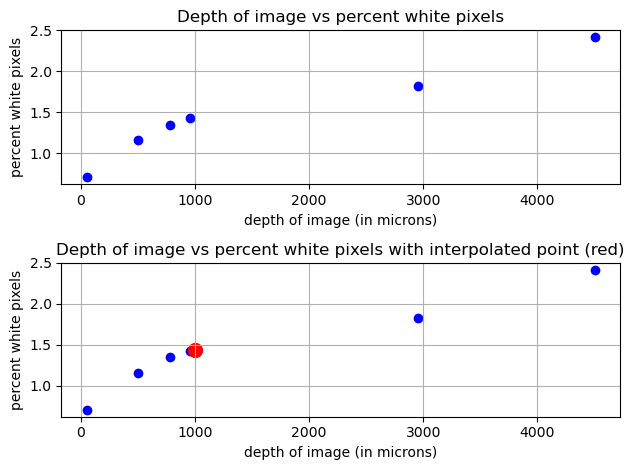

In [29]:
# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Depth of image vs percent white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('percent white pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
    'Depth of image vs percent white pixels with interpolated point (red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('percent white pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 
We were expecting a positive relationship between the depth of the cross section and the percent of pulmonary fibrosis, which the graph clearly shows. When we used linear and quadratic interpolation to evaluate the percent of fibrosis at other depths, it followed this same pattern, verifying this relationship. Additonally, an artical by Souza et al. mentions that basal and subpleural predominance is common in patients with IPF, meaning that fibrosis is worse in the lower lobes of the lungs and close to the pleura, the membrane that surrounds the lungs (2012). This information supports the relationship shown in our graph as it illustraits a positive relationship between lung depth and the percent of fibrosis (white pixels).


## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

##### Conclusions
- 

##### Ethical Implications
> Accuracy & Clinical Use ~ Quantitative image analysis must be highly accurate before being used in clinical decision-making, as errors could lead to misdiagnosis or incorrect assessment of disease severity.

> Data Interpretation ~ Simplifying complex biological tissue into binary images may overlook important structural details, potentially leading to incomplete or misleading conclusions.

> Bias and Generalizability ~ Results based on a limited set of images may not represent all patient populations, raising concerns about applying findings broadly without sufficient validation.

> Patient Impact ~ Over or underestimation of fibrosis could affect treatment decisions, patient prognosis, and quality of life, emphasizing the need for careful validation of computational methods.

> Data Privacy ~ When working with medical images, it is essential to ensure that patient data is anonymized and handled in compliance with privacy regulations.

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:

National Heart, Lung, and Blood Institute. (n.d.). Causes of idiopathic pulmonary fibrosis. Retrieved from https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis/causes

PMC. (2024). Epidemiology and burden of idiopathic pulmonary fibrosis. Retrieved from https://pmc.ncbi.nlm.nih.gov/articles/PMC12330001/

PMC. (2023). Pathogenesis and risk factors of idiopathic pulmonary fibrosis. Retrieved from https://pmc.ncbi.nlm.nih.gov/articles/PMC10398274/
